In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('superstore_sales_data.csv')

In [3]:
df.head(2)

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Profit,Returns,Payment Mode
0,CA-2019-160304,01-01-2019,07-01-2019,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,Maryland,East,FUR-BO-10004709,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Medium Ch...",73.94,1,28.2668,NaN,Online
1,CA-2019-160304,02-01-2019,07-01-2019,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,Maryland,East,FUR-BO-10004709,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Medium Ch...",173.94,3,38.2668,NaN,Online


# DATA CLEANING PART


In [4]:
# Column names clean
df.columns = df.columns.str.lower().str.replace(" ", "_")


In [5]:
df.head()

,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,region,product_id,category,sub-category,product_name,sales,quantity,profit,returns,payment_mode
0,CA-2019-160304,01-01-2019,07-01-2019,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,Maryland,East,FUR-BO-10004709,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Medium Ch...",73.94,1,28.2668,NaN,Online
1,CA-2019-160304,02-01-2019,07-01-2019,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,Maryland,East,FUR-BO-10004709,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Medium Ch...",173.94,3,38.2668,NaN,Online
2,CA-2019-160304,02-01-2019,07-01-2019,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,Maryland,East,TEC-PH-10000455,Technology,Phones,GE 30522EE2,231.98,2,67.2742,NaN,Cards
3,CA-2019-125206,03-01-2019,05-01-2019,First Class,LR-16915,Lena Radford,Consumer,United States,Los Angeles,California,West,OFF-ST-10003692,Office Supplies,Storage,Recycled Steel Personal File for Hanging File ...,114.46,2,28.6150,NaN,Online
4,US-2019-116365,03-01-2019,08-01-2019,Standard Class,CA-12310,Christine Abelman,Corporate,United States,San Antonio,Texas,Central,TEC-AC-10002217,Technology,Accessories,Imation Clip USB flash drive - 8 GB,30.08,2,-5.2640,NaN,Online


In [6]:
# Duplicate rows remove 
df = df.drop_duplicates(subset = ["order_id", "product_id"])

In [7]:
df.isnull().sum()

order_id            0
order_date          0
ship_date           0
ship_mode           0
customer_id         0
customer_name       0
segment             0
country             0
city                0
state               0
region              0
product_id          0
category            0
sub-category        0
product_name        0
sales               0
quantity            0
profit              0
returns          5607
payment_mode        0
dtype: int64

In [8]:
df["returns"].fillna("No", inplace=True)

C:\Users\royni\AppData\Local\Temp\ipykernel_20616\3276147477.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["returns"].fillna("No", inplace=True)
C:\Users\royni\AppData\Local\Temp\ipykernel_20616\3276147477.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'No' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df["returns"].fillna("No", inplace=True)


In [9]:
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")
df["ship_date"] = pd.to_datetime(df["ship_date"], errors="coerce")


In [10]:
#Invalid records remove
df = df[(df["sales"] > 0) & (df["quantity"] > 0)]
df = df[df["ship_date"] >= df["order_date"]]


In [11]:
#Categorical data clean
df["payment_mode"] = df["payment_mode"].str.strip().str.title()


#   BASICs QUESTIONS. 

In [12]:
# Total orders
df['order_id'].nunique()

825

In [13]:
# Total sales
df['sales'].sum()

np.float64(445004.7737)

In [14]:
# Average sales
df['sales'].mean()

np.float64(264.72621873884594)

In [15]:
# Total quantity sold
df['quantity'].sum()

np.int64(6378)

In [16]:
# Number of customers
df['customer_id'].nunique()

515

In [17]:
# Unique categories
df['category'].nunique()

3

In [18]:
# Orders per region
df['region'].value_counts()

region
West       553
East       457
Central    387
South      284
Name: count, dtype: int64

In [19]:
# Payment mode distribution
df['payment_mode'].value_counts()

payment_mode
Cod       709
Online    615
Cards     357
Name: count, dtype: int64

In [20]:
# Top 5 cities by orders
df['city'].value_counts().head(5)

city
New York City    159
Los Angeles      130
Philadelphia      91
San Francisco     87
Seattle           74
Name: count, dtype: int64

In [21]:
# Min & Max sales
df['sales'].min() , df['sales'].max()

(np.float64(1.728), np.float64(5399.91))

In [22]:
# Profit summary
df['profit'].describe()

count    1681.000000
mean       35.041258
std       285.718213
min     -3839.990400
25%         1.816000
50%         8.716800
75%        31.068800
max      8399.976000
Name: profit, dtype: float64

In [23]:
# Orders per segment
df['segment'].value_counts()

segment
Consumer       891
Corporate      459
Home Office    331
Name: count, dtype: int64

In [24]:
# Returned orders count
df['returns'].value_counts()

returns
No     1631
1.0      50
Name: count, dtype: int64

In [25]:
# Orders per ship mode
df['ship_mode'].value_counts()

ship_mode
Standard Class    831
Second Class      340
First Class       337
Same Day          173
Name: count, dtype: int64

In [26]:
# Category-wise sales
df.groupby('category')['sales'].sum()

category
Furniture          127325.1187
Office Supplies    161380.4020
Technology         156299.2530
Name: sales, dtype: float64

In [27]:
# Category-wise profit
df.groupby('category')['profit'].sum()

category
Furniture           3119.9638
Office Supplies    20121.6340
Technology         35662.7561
Name: profit, dtype: float64

In [28]:
# Most sold product
df['product_name'].value_counts()

product_name
Easy-staple paper                                                       16
Staples                                                                 10
Logitech MX Performance Wireless Mouse                                   7
Xerox 191                                                                6
Xerox 1996                                                               5
                                                                        ..
BIC Liqua Brite Liner                                                    1
Jackery Bar Premium Fast-charging Portable Charger                       1
Tripp Lite Isotel 6 Outlet Surge Protector with Fax/Modem Protection     1
Convenience Packs of Business Envelopes                                  1
Col-Erase Pencils with Erasers                                           1
Name: count, Length: 1090, dtype: int64

In [29]:
# Least profitable order
df.sort_values('profit').head(3)

,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,region,product_id,category,sub-category,product_name,sales,quantity,profit,returns,payment_mode
5037,US-2020-168116,2020-04-11,2020-04-11,Same Day,GT-14635,Grant Thornton,Corporate,United States,Burlington,North Carolina,South,TEC-MA-10004125,Technology,Machines,Cubify CubeX 3D Printer Triple Head Print,3009.980,4,-3839.9904,No,Online
383,CA-2019-130946,2019-08-04,2019-12-04,Standard Class,ZC-21910,Zuschuss Carroll,Consumer,United States,Houston,Texas,Central,OFF-BI-10004995,Office Supplies,Binders,GBC DocuBind P400 Electric Binding System,1088.792,4,-1850.9464,No,Online
4702,US-2020-162558,2020-02-10,2020-05-10,First Class,Dp-13240,Dean percer,Home Office,United States,Knoxville,Tennessee,South,FUR-TA-10000198,Furniture,Tables,Chromcraft Bull-Nose Wood Oval Conference Tabl...,2335.116,7,-1002.7836,No,Online


In [30]:
# Orders per year
df['order_date'].dt.year.value_counts()

order_date
2020    937
2019    744
Name: count, dtype: int64

# **************************** 20 MORE QUESTIONS ****************************

In [31]:
# Sales by region
df.groupby('region')['sales'].sum()

region
Central     94118.6862
East       116760.9320
South       77549.9265
West       156575.2290
Name: sales, dtype: float64

In [32]:
# Monthly sales trend
df.groupby(df['order_date'].dt.to_period('M'))['sales'].sum()

order_date
2019-01    26367.3610
2019-02    19424.7950
2019-03    26053.3750
2019-04    22296.3940
2019-05    21777.4588
2019-06    15078.0130
2019-07    15919.8960
2019-08    15649.7406
2019-09     3501.9180
2019-10     7620.9370
2019-11     3312.1000
2019-12      409.1250
2020-01    39486.9120
2020-02    47970.4560
2020-03    40340.1370
2020-04    23787.7670
2020-05    23902.1570
2020-06    15423.6658
2020-07    26703.9855
2020-08    18340.4010
2020-09    10972.8010
2020-10     7449.1600
2020-11     8448.7240
2020-12     4767.4940
Freq: M, Name: sales, dtype: float64

In [33]:
# Top 10 profitable products
df.groupby('product_name')['profit'].sum().sort_values(ascending = False).head(10)

product_name
Canon imageCLASS 2200 Advanced Copier                                 8399.9760
HP Designjet T520 Inkjet Large Format Printer - 24" Color             2799.9840
Hewlett Packard LaserJet 3310 Copier                                  2591.9568
Ativa V4110MDD Micro-Cut Shredder                                     2400.9657
Canon PC1060 Personal Laser Copier                                    1889.9730
Honeywell Enviracaire Portable HEPA Air Cleaner for 17' x 22' Room    1785.8610
Canon Imageclass D680 Copier / Fax                                    1679.9760
Hon Deluxe Fabric Upholstered Stacking Chairs, Rounded Back           1537.0740
3D Systems Cube Printer, 2nd Generation, Magenta                      1351.9896
Maxell iVDR EX 500GB Cartridge                                        1184.8220
Name: profit, dtype: float64

In [34]:
# Category + Sub-category sales
df.groupby(["category", "sub-category"])['sales'].sum()

category         sub-category
Furniture        Bookcases       17128.4912
                 Chairs          48460.9070
                 Furnishings     24535.4080
                 Tables          37200.3125
Office Supplies  Appliances      21978.8720
                 Art             11986.4940
                 Binders         41584.6620
                 Envelopes        4180.8740
                 Fasteners        2985.5720
                 Labels           5675.9200
                 Paper           29705.6940
                 Storage         36329.9560
                 Supplies         6952.3580
Technology       Accessories     35720.6580
                 Copiers         23541.5140
                 Machines        44998.4270
                 Phones          52038.6540
Name: sales, dtype: float64

In [35]:
# Average order value
df.groupby("order_id")["sales"].sum().mean()


np.float64(539.3997256969698)

In [36]:
# Loss-making orders
df[df['profit'] < 0 ].head(5)

,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,region,product_id,category,sub-category,product_name,sales,quantity,profit,returns,payment_mode
4,US-2019-116365,2019-03-01,2019-08-01,Standard Class,CA-12310,Christine Abelman,Corporate,United States,San Antonio,Texas,Central,TEC-AC-10002217,Technology,Accessories,Imation Clip USB flash drive - 8 GB,30.080,2,-5.2640,No,Online
5,US-2019-116365,2019-03-01,2019-08-01,Standard Class,CA-12310,Christine Abelman,Corporate,United States,San Antonio,Texas,Central,TEC-AC-10002942,Technology,Accessories,WD My Passport Ultra 1TB Portable External Har...,165.600,3,-6.2100,No,Online
11,CA-2019-158211,2019-04-01,2019-08-01,Standard Class,BP-11185,Ben Peterman,Corporate,United States,Philadelphia,Pennsylvania,East,OFF-BI-10002026,Office Supplies,Binders,Avery Arch Ring Binders,104.580,6,-80.1780,No,Online
16,CA-2019-158806,2019-07-01,2019-11-01,Standard Class,NM-18520,Neoma Murray,Consumer,United States,Amarillo,Texas,Central,FUR-FU-10004270,Furniture,Furnishings,"Executive Impressions 13"" Clairmont Wall Clock",23.076,3,-10.9611,No,Cod
96,CA-2019-144645,2019-02-02,2019-08-02,Standard Class,NS-18640,Noel Staavos,Corporate,United States,Houston,Texas,Central,FUR-FU-10003601,Furniture,Furnishings,"Deflect-o RollaMat Studded, Beveled Mat for Me...",73.784,2,-77.4732,No,Cod


In [37]:
# Payment mode vs sales
df.groupby("payment_mode")["sales"].sum()


payment_mode
Cards     102099.7394
Cod       182393.1765
Online    160511.8578
Name: sales, dtype: float64

In [38]:
# Return rate
df["returns"].value_counts(normalize=True) * 100


returns
No     97.02558
1.0     2.97442
Name: proportion, dtype: float64

In [39]:
# Sales per customer
df.groupby("customer_id")["sales"].sum().head(5)


customer_id
AA-10315    4406.072
AA-10375     263.860
AA-10645    1757.145
AB-10015     563.940
AB-10060    4940.706
Name: sales, dtype: float64

In [44]:
# Top customers
df.groupby("customer_name")["sales"].sum().sort_values(ascending=False).head()


customer_name
Caroline Jumper    9115.494
Karen Ferguson     7297.054
Karen Daniels      6317.162
Helen Wasserman    5877.166
Todd Sumrall       5594.142
Name: sales, dtype: float64

In [43]:
# Shipping delay.
df['shipping_days'] = (df['ship_date'] - df['order_date']).dt.days

In [45]:
df[['order_date', 'ship_date', 'shipping_days']].head()


,order_date,ship_date,shipping_days
0,2019-01-01,2019-07-01,181
2,2019-02-01,2019-07-01,150
3,2019-03-01,2019-05-01,61
4,2019-03-01,2019-08-01,153
5,2019-03-01,2019-08-01,153


In [46]:
# Avg shipping time.
df['shipping_days'].mean()

np.float64(102.96728138013087)

In [47]:
# Region-wise shipping time.
df.groupby("region")["shipping_days"].mean()
df.groupby('region')['shipping_days'].mean()

region
Central    110.666667
East       108.017505
South       95.630282
West        97.173599
Name: shipping_days, dtype: float64

In [48]:
# Quantity vs profit.
df.groupby('quantity')['profit'].sum()

quantity
1      1101.9293
2      7876.6774
3      7248.1518
4      1791.1892
5     21534.0845
6      3219.9348
7      5969.4019
8      3818.6688
9      4544.6256
10      193.2690
11     1185.6130
12      147.8172
13      168.1524
14      104.8390
Name: profit, dtype: float64

In [49]:
# Sales growth year-wise
df.groupby(df['order_date'].dt.year)['sales'].sum().pct_change()

order_date
2019         NaN
2020    0.508325
Name: sales, dtype: float64

In [53]:
# Orders per city & state.
df.groupby(['state','city']).size()

state      city      
Alabama    Decatur       1
           Florence      1
           Huntsville    1
           Montgomery    1
Arizona    Chandler      1
                        ..
Wisconsin  Franklin      7
           Madison       2
           Milwaukee     4
           Waukesha      1
Wyoming    Cheyenne      1
Length: 270, dtype: int64

In [55]:
# Best shipping mode.
df.groupby('ship_mode')['profit'].sum()

ship_mode
First Class        8400.7542
Same Day           2970.9413
Second Class      12126.0420
Standard Class    35406.6164
Name: profit, dtype: float64

# 20. MORE QUESTIONS 

In [58]:
# RFM – Revenue per customer
df.groupby('customer_id')['sales'].sum()

customer_id
AA-10315    4406.072
AA-10375     263.860
AA-10645    1757.145
AB-10015     563.940
AB-10060    4940.706
              ...   
XP-21865    1070.222
YC-21895    1571.480
YS-21880     229.052
ZC-21910    1940.394
ZD-21925    1187.744
Name: sales, Length: 515, dtype: float64

In [59]:
# Top 20% customers.
df.groupby('customer_id')['sales'].sum().quantile(0.8)

np.float64(1302.4370000000017)

In [65]:
# Cohort analysis (year).

df['order_year'] = df['order_date'].dt.year
df.groupby('order_year')['customer_id'].nunique()

order_year
2019    291
2020    364
Name: customer_id, dtype: int64

In [67]:
# Repeat customers.

df['customer_id'].value_counts()[lambda x: x > 1]

customer_id
BF-11020    17
LB-16795    14
FM-14290    13
Dp-13240    13
WB-21850    13
            ..
AD-10180     2
JS-16030     2
LC-17050     2
JB-15400     2
JG-15310     2
Name: count, Length: 367, dtype: int64

In [68]:
# Customer lifetime value.

df.groupby('customer_id')['profit'].sum()

customer_id
AA-10315    -747.1021
AA-10375      26.5552
AA-10645     340.8478
AB-10015     116.8680
AB-10060    1574.6518
              ...    
XP-21865     361.9540
YC-21895     427.2667
YS-21880      17.0772
ZC-21910   -1778.0546
ZD-21925     206.6645
Name: profit, Length: 515, dtype: float64

In [70]:
# Loss-heavy categories.

df.groupby('category')['profit'].mean()

category
Furniture            8.763943
Office Supplies     19.961938
Technology         112.500808
Name: profit, dtype: float64

In [72]:
# High return customers
df[df['returns'] == 'yes']['customer_id'].value_counts()

Series([], Name: count, dtype: int64)

In [74]:
df[df["returns"]=="Yes"]["customer_id"].value_counts()


Series([], Name: count, dtype: int64)

<Axes: xlabel='sales', ylabel='profit'>

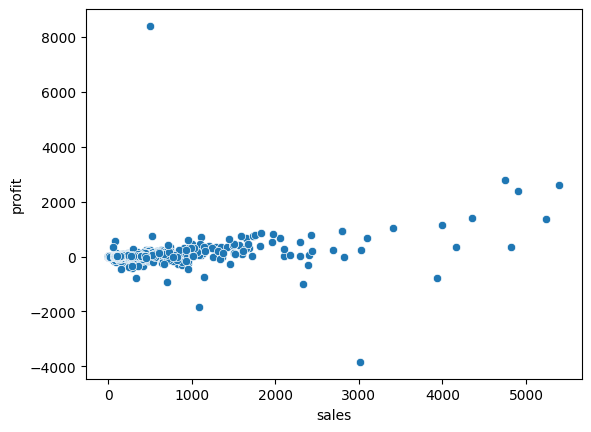

In [75]:
sns.scatterplot(x="sales", y="profit", data=df)


In [76]:
# Monthly profit trend.
df.groupby(df["order_date"].dt.to_period("M"))["profit"].sum()


order_date
2019-01     7062.6380
2019-02    13852.9076
2019-03     1519.3043
2019-04     5031.8337
2019-05     3226.0823
2019-06     1384.4049
2019-07     3615.8458
2019-08     -248.4211
2019-09      428.0622
2019-10      504.7781
2019-11       28.4422
2019-12       65.5695
2020-01     3579.1471
2020-02     3050.2956
2020-03     5375.1212
2020-04    -3331.9578
2020-05     2757.0562
2020-06     1562.2207
2020-07     3092.5454
2020-08     2938.5083
2020-09     2009.1679
2020-10       99.7206
2020-11      952.8735
2020-12      348.2077
Freq: M, Name: profit, dtype: float64

In [77]:
# Customer churn proxy.
df.groupby("customer_id")["order_date"].max()


customer_id
AA-10315   2019-03-03
AA-10375   2020-07-09
AA-10645   2020-05-11
AB-10015   2019-10-11
AB-10060   2020-07-05
              ...    
XP-21865   2020-09-10
YC-21895   2019-07-04
YS-21880   2020-05-05
ZC-21910   2020-06-11
ZD-21925   2019-08-07
Name: order_date, Length: 515, dtype: datetime64[ns]

In [78]:
# Final KPI summary.

df[["sales","profit","quantity"]].agg(["sum","mean","max"])


,sales,profit,quantity
sum,445004.773700,58904.353900,6378.00000
mean,264.726219,35.041258,3.79417
max,5399.910000,8399.976000,14.00000
